# Exploratory Data Analysis & Business Insights

## Objective

The objective of this notebook is to analyze the processed e-commerce sales dataset and answer key business questions related to product performance, regional performance, customer segments, discounts, and sales trends.

The insights generated from this analysis can help support data-driven business decisions.

## Import Required Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Load Processed Dataset

In [2]:
df = pd.read_csv("../data/ecommerce_feature_engineered.csv")
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Year,Month,Quarter
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136,2016,11,4
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820,2016,11,4
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714,2016,6,2
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310,2015,10,4
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164,2015,10,4


## Dataset Ready for Analysis

The cleaned dataset is loaded successfully and is now ready for exploratory data analysis.

In [3]:
df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit', 'Year',
       'Month', 'Quarter'],
      dtype='str')

# Business Objective 1

## Analyze Product Performance

This section evaluates the performance of product categories and sub-categories to identify which products contribute the most to sales and profitability.

## Business Question 1

### Which product category generates the highest total sales?

In [4]:
## CATEGORY HAS HIGHEST SALE
category_with_sale = df.groupby("Category")["Sales"].sum().reset_index()
category_with_sale


,Category,Sales
0,Furniture,741999.7953
1,Office Supplies,719047.0320
2,Technology,836154.0330


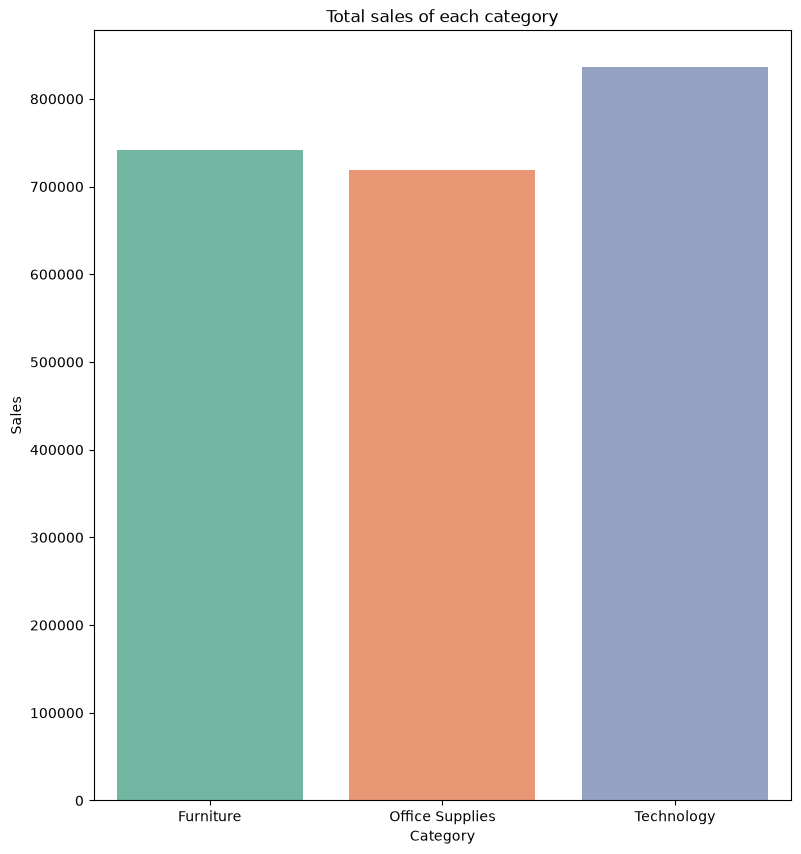

In [5]:
plt.figure(figsize=(9,10))

sns.barplot(x="Category",y="Sales",data=category_with_sale,hue="Category",palette="Set2",legend=False)
plt.title("Total sales of each category")
plt.show()

### Observation

Technology generated the highest total sales (836,154), followed by Furniture (741,999). Office Supplies recorded the lowest sales among the three categories.

### Insight

Technology is the strongest revenue-generating category, indicating high customer demand for technology products.

### Recommendation

Continue maintaining inventory for high-selling Technology products and identify the best-performing items that contribute most to sales.

## Business Question 2

### Which product category generates the highest total profit?

In [6]:
## Category with highest profit
category_with_profit = df.groupby("Category")["Profit"].sum().reset_index()
category_with_profit

,Category,Profit
0,Furniture,18451.2728
1,Office Supplies,122490.8008
2,Technology,145454.9481


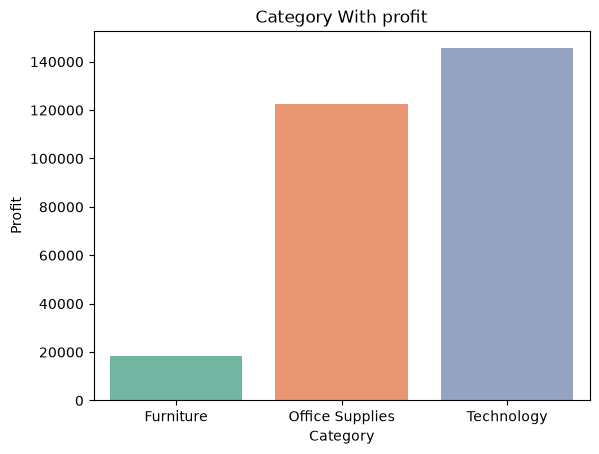

In [7]:
sns.barplot(x="Category",y="Profit",data=category_with_profit,hue="Category",palette="Set2",legend=False)
plt.title("Category With profit")
plt.show()

### Observation

Technology generated the highest total profit, while Furniture generated the lowest profit.

### Insight

Although Furniture contributes strong sales, it generates comparatively lower profit, suggesting lower profit margins.



## Business Question 3

### Which product sub-category generates the highest and lowest profit?

In [8]:
sub_category = df.groupby("Sub-Category")["Profit"].sum().reset_index().sort_values(by="Profit", ascending=False)
sub_category

,Sub-Category,Profit
6,Copiers,55617.8249
13,Phones,44515.7306
0,Accessories,41936.6357
12,Paper,34053.5693
3,Binders,30221.7633
5,Chairs,26590.1663
14,Storage,21278.8264
1,Appliances,18138.0054
9,Furnishings,13059.1436
7,Envelopes,6964.1767


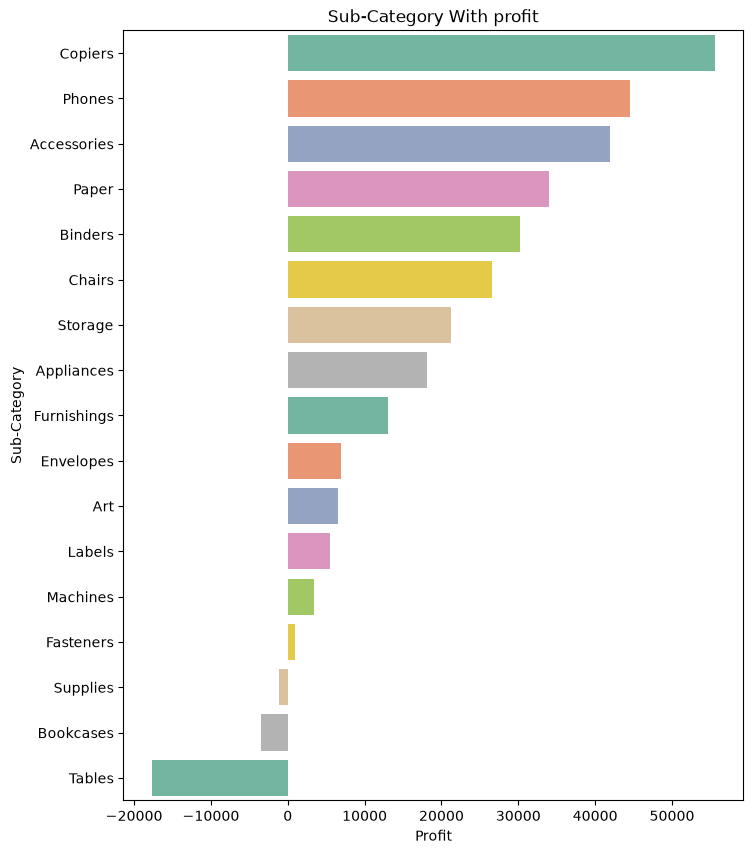

In [9]:
plt.figure(figsize=(8,10))
sns.barplot(x="Profit",y="Sub-Category",data=sub_category,hue="Sub-Category",palette="Set2",legend=False)
plt.title("Sub-Category With profit")
plt.show()

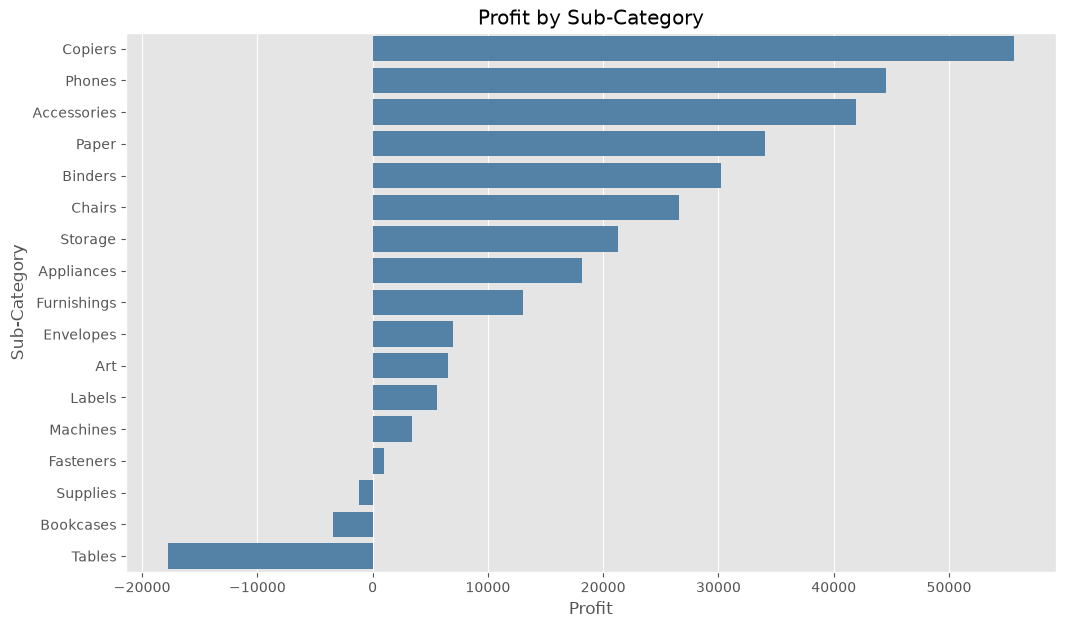

In [10]:
plt.style.use("ggplot")

plt.figure(figsize=(12, 7))

sns.barplot(
    data=sub_category,
    x="Profit",
    y="Sub-Category",
    color="steelblue"
)


plt.title("Profit by Sub-Category")
plt.xlabel("Profit")
plt.ylabel("Sub-Category")

plt.show()

### Observation

Copiers generated the highest profit, whereas Tables recorded an overall loss.

### Insight

The profitability of sub-categories varies significantly. Tables require further investigation as they are reducing overall profit.

### Recommendation

Analyze the pricing, discounts, and sales trends of Tables before making inventory or pricing decisions.

## Business Question 4

### Which product sub-category generates the highest total sales?

In [11]:
df.groupby("Sub-Category")["Sales"].sum().reset_index()

,Sub-Category,Sales
0,Accessories,167380.3180
1,Appliances,107532.1610
2,Art,27118.7920
3,Binders,203412.7330
4,Bookcases,114879.9963
5,Chairs,328449.1030
6,Copiers,149528.0300
7,Envelopes,16476.4020
8,Fasteners,3024.2800
9,Furnishings,91705.1640


### Observation

Chairs generated the highest total sales among all sub-categories.

### Insight

Chairs are one of the major revenue-driving products and contribute significantly to total sales.

### Recommendation

Maintain sufficient inventory of Chairs and identify the products contributing most to this category's sales.

## Business Question 5

### Is discount one of the possible reasons for low profitability in certain sub-categories?

In [12]:
df.groupby("Sub-Category")["Discount"].mean().reset_index()

,Sub-Category,Discount
0,Accessories,0.078452
1,Appliances,0.166524
2,Art,0.074874
3,Binders,0.372292
4,Bookcases,0.211140
5,Chairs,0.170178
6,Copiers,0.161765
7,Envelopes,0.080315
8,Fasteners,0.082028
9,Furnishings,0.138349


### Observation

Average discounts vary across different sub-categories. However, the discount pattern alone does not fully explain why some products generate low or negative profit.

### Insight

Profitability is influenced by multiple factors. Discount is one factor, but pricing, sales volume, and product mix may also affect profit.

### Recommendation

Review discount strategies together with pricing and sales performance before changing the current discount policy.

# Business Objective 2

## Analyze Regional Performance

This section analyzes sales and profit across different regions and states to identify the best-performing and underperforming locations.

## Business Question 1

### Which region generates the highest total sales?

In [13]:
# Region with highest sales

region_sales = df.groupby("Region")["Sales"].sum().reset_index()
region_sales

,Region,Sales
0,Central,501239.8908
1,East,678781.2400
2,South,391721.9050
3,West,725457.8245


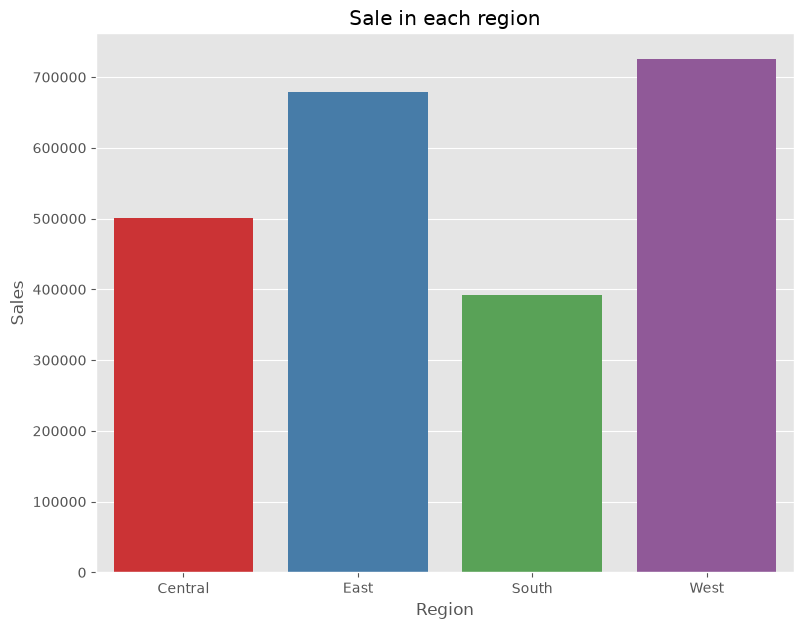

In [14]:
plt.figure(figsize=(9,7))
sns.barplot(x="Region",y="Sales",data=region_sales,hue="Region",palette="Set1",legend=False)
plt.title("Sale in each region")
plt.show()

### Observation

The West region generated the highest total sales, while the South region recorded the lowest sales.

### Insight

Sales performance varies across regions, indicating that customer demand is stronger in some regions than others.

### Recommendation

Study the successful sales strategies used in the West region and identify opportunities to improve sales in lower-performing regions.

## Business Question 2

### Which region generates the highest total profit?

In [15]:
### REGION WITH PROFIT

region_profit = df.groupby("Region")["Profit"].sum().reset_index()
region_profit

,Region,Profit
0,Central,39706.3625
1,East,91522.7800
2,South,46749.4303
3,West,108418.4489


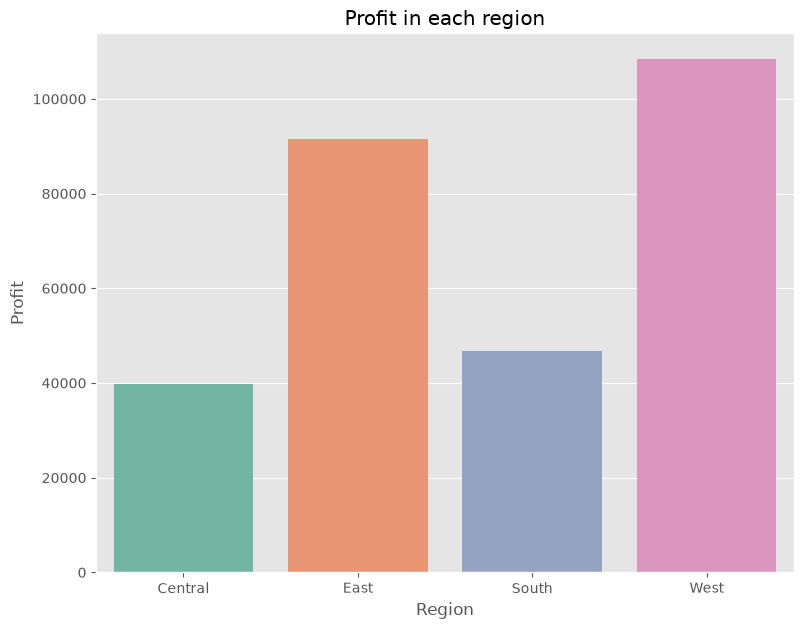

In [16]:
plt.figure(figsize=(9,7))
sns.barplot(x="Region",y="Profit",data=region_profit,hue="Region",palette="Set2",legend=False)
plt.title("Profit in each region")
plt.show()

### Observation

The West region generated the highest total profit, whereas the Central region recorded the lowest profit.

### Insight

High sales do not always guarantee high profit. Profitability depends on factors such as discounts, product mix, and operational performance.

### Recommendation

Review the performance of low-profit regions to identify the factors reducing profitability.

## Business Question 3

### Which states generate the highest total sales?

In [17]:
state_sales = df.groupby("State")["Sales"].sum().reset_index().sort_values(by="Sales", ascending=False).head(10)
state_sales


,State,Sales
3,California,457687.6315
30,New York,310876.2710
41,Texas,170188.0458
45,Washington,138641.2700
36,Pennsylvania,116511.9140
8,Florida,89473.7080
11,Illinois,80166.1010
33,Ohio,78258.1360
20,Michigan,76269.6140
44,Virginia,70636.7200


<Axes: xlabel='Sales', ylabel='State'>

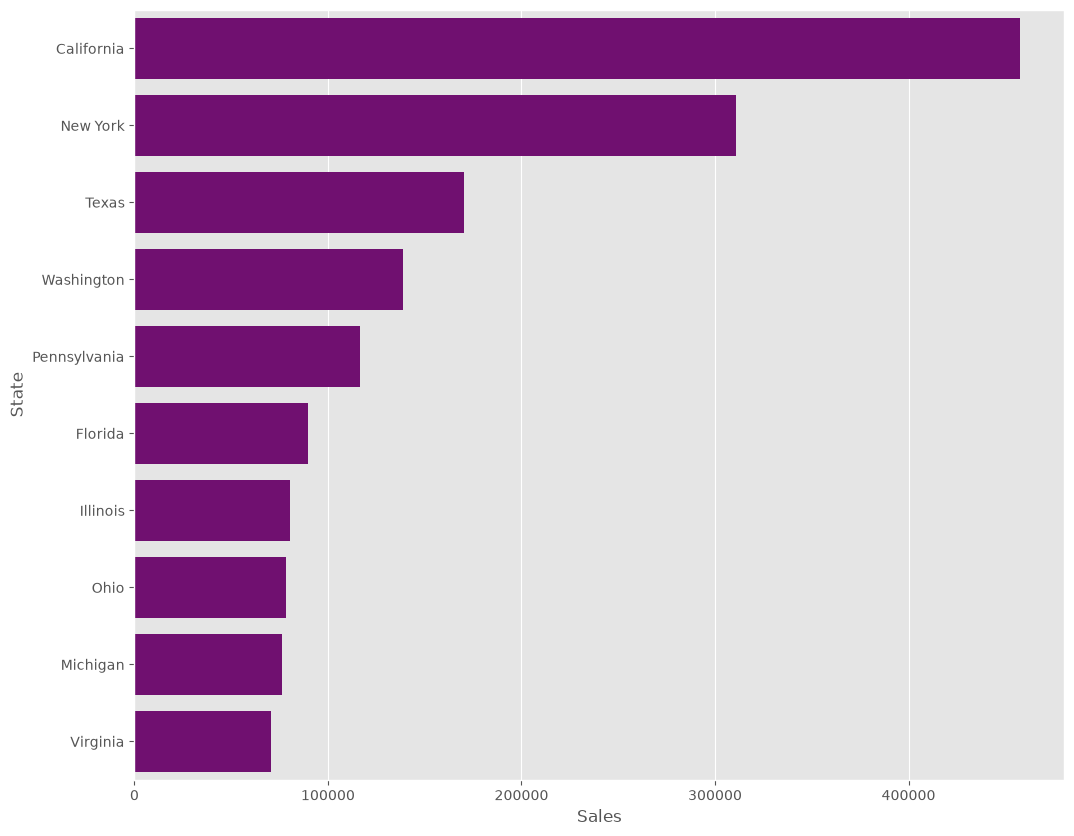

In [18]:
plt.figure(figsize=(12,10))
sns.barplot(data=state_sales,x="Sales",y="State",color="purple")

### Observation

A small number of states contribute a large share of total sales, while many states generate comparatively lower sales.

### Insight

Sales are concentrated in a few high-performing states, making them important contributors to overall business revenue.

### Recommendation

Maintain strong customer engagement in top-performing states while exploring growth opportunities in lower-performing markets.

## Business Question 4

### Which states generate the highest total profit?

In [19]:
### Top 10 sates with highest profits 
state_profit = df.groupby("State")["Profit"].sum().reset_index().sort_values(by="Profit", ascending=False).head(10)
state_profit

,State,Profit
3,California,76381.3871
30,New York,74038.5486
45,Washington,33402.6517
20,Michigan,24463.1876
44,Virginia,18597.9504
12,Indiana,18382.9363
9,Georgia,16250.0433
15,Kentucky,11199.6966
21,Minnesota,10823.1874
6,Delaware,9977.3748


<Axes: xlabel='Profit', ylabel='State'>

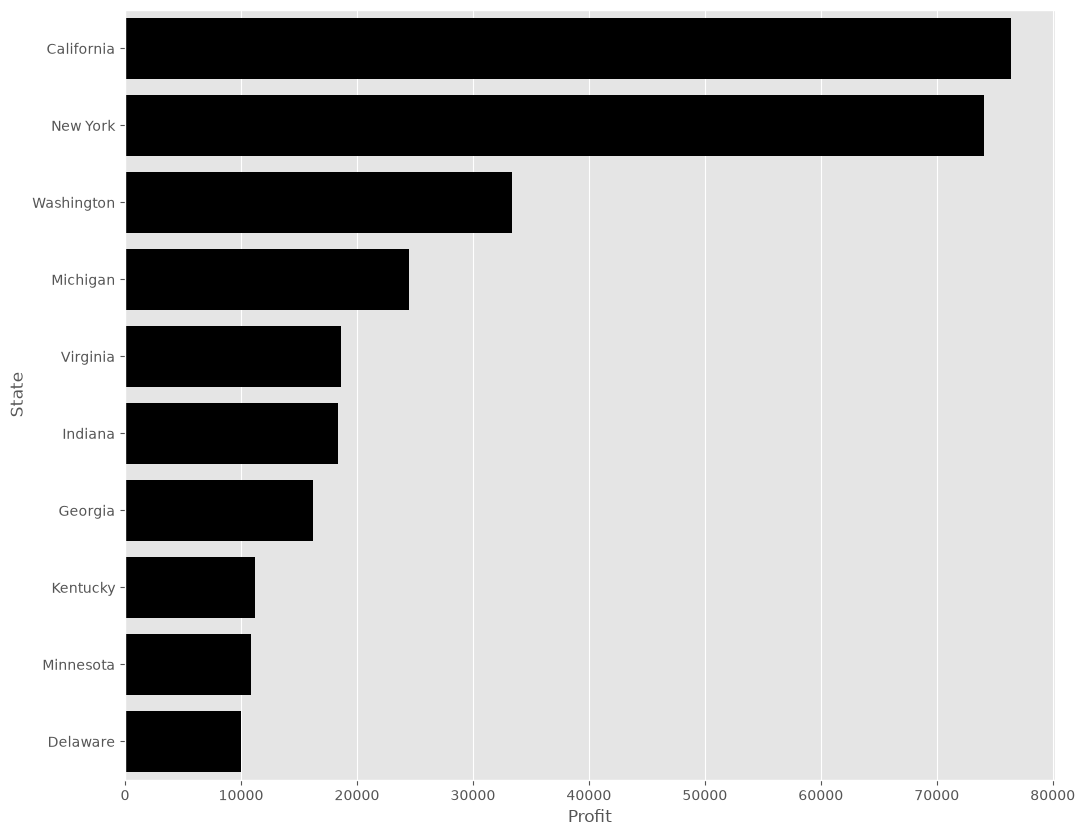

In [20]:
plt.figure(figsize=(12,10))
sns.barplot(data=state_profit,x="Profit",y="State",color="black")

### Observation

The highest profits are generated by only a few states, whereas several states contribute relatively little profit.

### Insight

Profitability is uneven across different states, suggesting that regional business performance differs significantly.

### Recommendation

Identify the business practices used in high-profit states and evaluate whether similar strategies can be applied elsewhere.

## Business Question 5

### Which states are operating at a loss?

In [21]:
loss_states = (df.groupby("State")["Profit"].sum().reset_index())

loss_states = loss_states[loss_states["Profit"] < 0]

loss_states

,State,Profit
1,Arizona,-3427.9246
4,Colorado,-6527.8579
8,Florida,-3399.3017
11,Illinois,-12607.8870
31,North Carolina,-7490.9122
33,Ohio,-16971.3766
35,Oregon,-1190.4705
36,Pennsylvania,-15559.9603
40,Tennessee,-5341.6936
41,Texas,-25729.3563


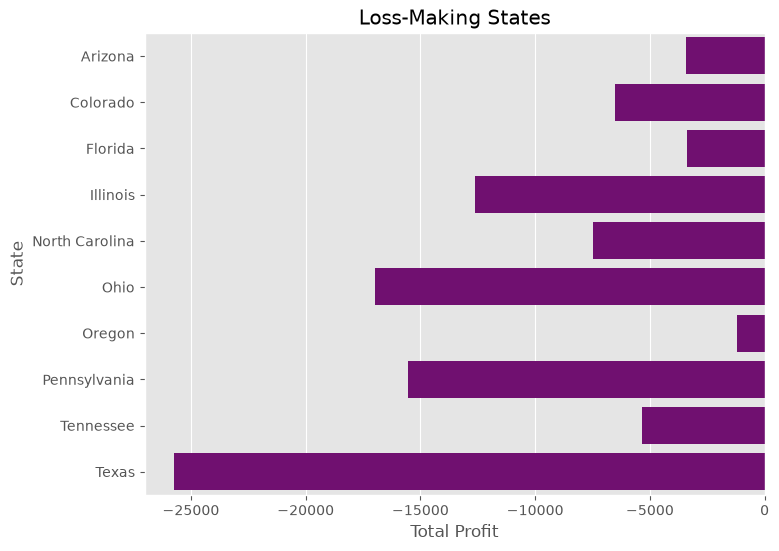

In [22]:
plt.figure(figsize=(8,6))

sns.barplot(x="Profit",y="State",data=loss_states,color="purple")

plt.title("Loss-Making States")
plt.xlabel("Total Profit")
plt.ylabel("State")

plt.show()

### Observation

Several states recorded negative profit, indicating that the company is losing money in those locations.

### Insight

Consistent losses suggest that current pricing, discounts, or product demand may not be sufficient to generate profit in those states.

### Recommendation

Conduct a detailed analysis of loss-making states and review pricing, discount policies, and product performance before expanding business in those regions.

# Business Objective 3

## Analyze Customer Segment Performance

This section evaluates the performance of different customer segments based on sales, profit, and discounts to understand which customer group contributes the most to the business.

## Business Question 1

### Which customer segment generates the highest total sales?

In [23]:
pd.set_option("display.float_format", "{:,.2f}".format)
customer_segment_sales = df.groupby("Segment")["Sales"].sum().reset_index()
customer_segment_sales

,Segment,Sales
0,Consumer,"1,161,401.34"
1,Corporate,"706,146.37"
2,Home Office,"429,653.15"


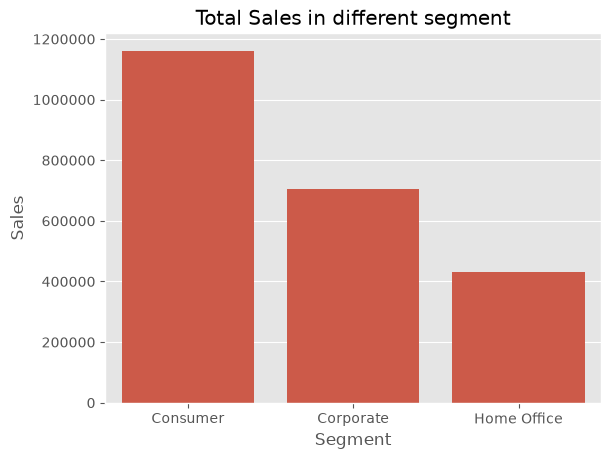

In [24]:
plt.ticklabel_format(style='plain', axis='y')
sns.barplot(x="Segment",y="Sales",data=customer_segment_sales)
plt.title("Total Sales in different segment")
plt.show()

### Observation

The Consumer segment generated the highest total sales, followed by Corporate. Home Office recorded the lowest sales.

### Insight

The Consumer segment is the company's primary source of revenue and contributes the largest share of overall sales.

### Recommendation

Continue focusing on the Consumer segment while exploring strategies to increase sales from Corporate and Home Office customers.

## Business Question 2

### Which customer segment generates the highest total profit?

In [25]:
segment_profit = (df.groupby("Segment")["Profit"].sum().reset_index())
segment_profit

,Segment,Profit
0,Consumer,"134,119.21"
1,Corporate,"91,979.13"
2,Home Office,"60,298.68"


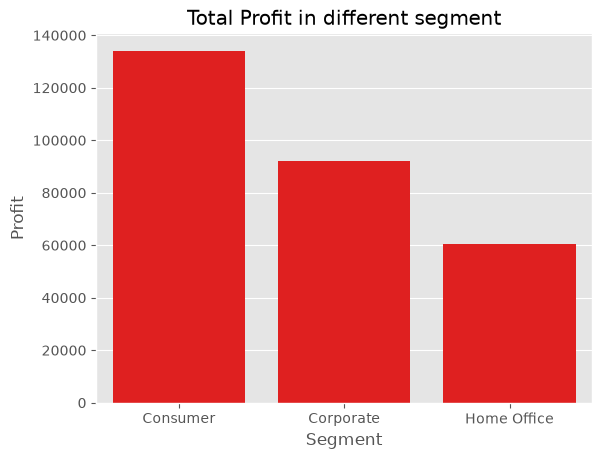

In [26]:
sns.barplot(x="Segment",y="Profit",data=segment_profit,color="red")
plt.title("Total Profit in different segment")
plt.show()

### Observation

The Consumer segment generated the highest total profit, while the Home Office segment generated the lowest profit.

### Insight

The Consumer segment contributes not only the highest sales but also the highest profit, making it the most valuable customer segment.

### Recommendation

Maintain strong engagement with Consumer customers and identify opportunities to improve profitability from the other customer segments.

## Business Question 3

### Which customer segment receives the highest average discount?

In [27]:
segment_discount = df.groupby("Segment")["Discount"].mean().reset_index()
segment_discount

,Segment,Discount
0,Consumer,0.16
1,Corporate,0.16
2,Home Office,0.15


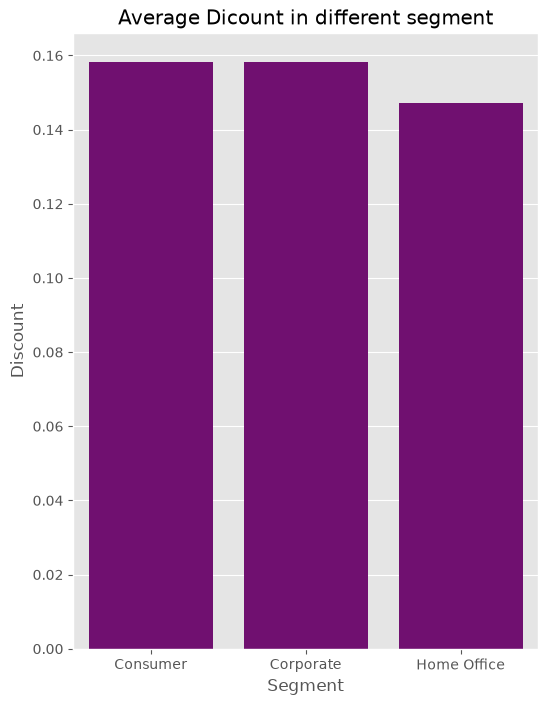

In [28]:
plt.figure(figsize=(6,8))
sns.barplot(x="Segment",y="Discount",data=segment_discount,color="purple")
plt.title("Average Dicount in different segment")
plt.show()

### Observation

The Consumer and Corporate segments receive almost the same average discount, while the Home Office segment receives a slightly lower average discount.

### Insight

The discount strategy is fairly consistent across customer segments, with only minor differences in the average discount offered.

### Recommendation

Since discount differences are minimal, focus on other factors such as product mix and customer purchasing behavior to improve profitability.

In [29]:
discount_profit = df.groupby("Segment")[["Discount","Profit"]].mean().reset_index()
discount_profit

,Segment,Discount,Profit
0,Consumer,0.16,25.84
1,Corporate,0.16,30.46
2,Home Office,0.15,33.82


## Business Question 4

### Is there a relationship between discount and profit across customer segments?

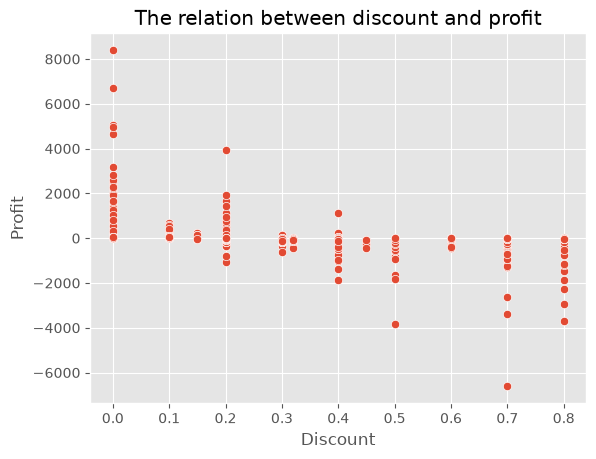

In [30]:
sns.scatterplot(x="Discount", y="Profit", data=df)
plt.title("The relation between discount and profit")
plt.show()

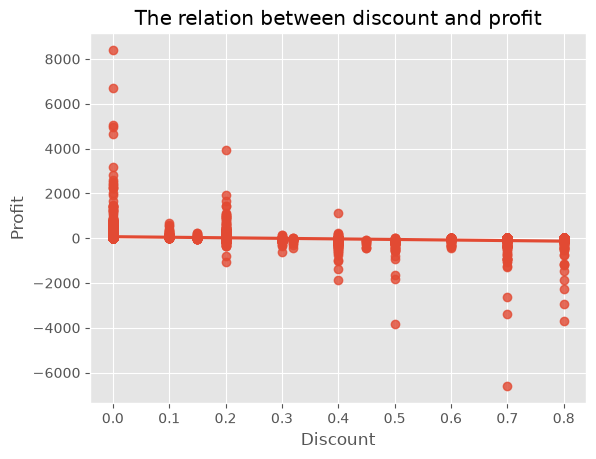

In [31]:
sns.regplot(x="Discount", y="Profit", data=df)
plt.title("The relation between discount and profit")
plt.show()

### Observation

The scatter plot shows that higher discounts are generally associated with lower profit. As discount increases, profit tends to decrease across many transactions.

### Insight

Although discounts may help increase sales, excessive discounts can reduce overall profitability. However, discount is only one of several factors affecting profit.

### Recommendation

Review the current discount strategy and avoid offering high discounts unless they contribute to increased sales or long-term customer value.

# Business Objective 4

## Analyze Discount Impact

This section analyzes how discounts vary across different product categories, sub-categories, regions, and states, and examines their relationship with profitability.

## Business Question 1

### Which product category receives the highest average discount?

In [32]:
category_discount = df.groupby("Category")["Discount"].mean().reset_index()
category_discount

,Category,Discount
0,Furniture,0.17
1,Office Supplies,0.16
2,Technology,0.13


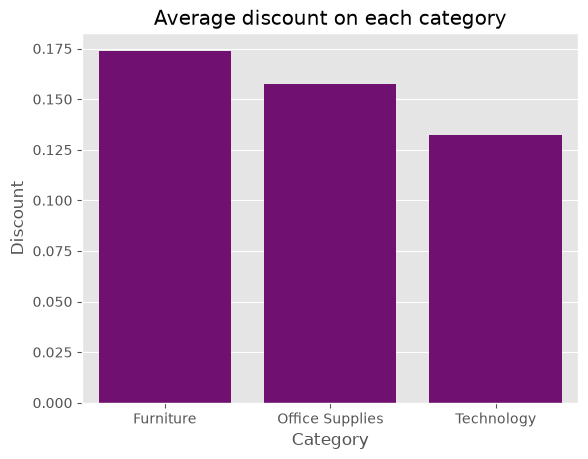

In [33]:
sns.barplot(x="Category",y="Discount",data=category_discount,color="purple")
plt.title("Average discount on each category")
plt.show()

### Observation

Furniture receives the highest average discount (0.07), followed by Office Supplies (0.06). Technology receives the lowest average discount (0.13).

### Insight

The company offers larger discounts on Furniture than on the other two categories. Despite these higher discounts, Furniture is not the most profitable category, indicating that discounting may be affecting its profitability.

### Recommendation

Review the current discount strategy for Furniture products and identify whether all discounts are necessary or if they can be optimized without reducing sales.

## Business Question 2

### Which product sub-category receives the highest average discount?

In [34]:
sub_category_discount = df.groupby("Sub-Category")["Discount"].mean().reset_index()
sub_category_discount

,Sub-Category,Discount
0,Accessories,0.08
1,Appliances,0.17
2,Art,0.07
3,Binders,0.37
4,Bookcases,0.21
5,Chairs,0.17
6,Copiers,0.16
7,Envelopes,0.08
8,Fasteners,0.08
9,Furnishings,0.14


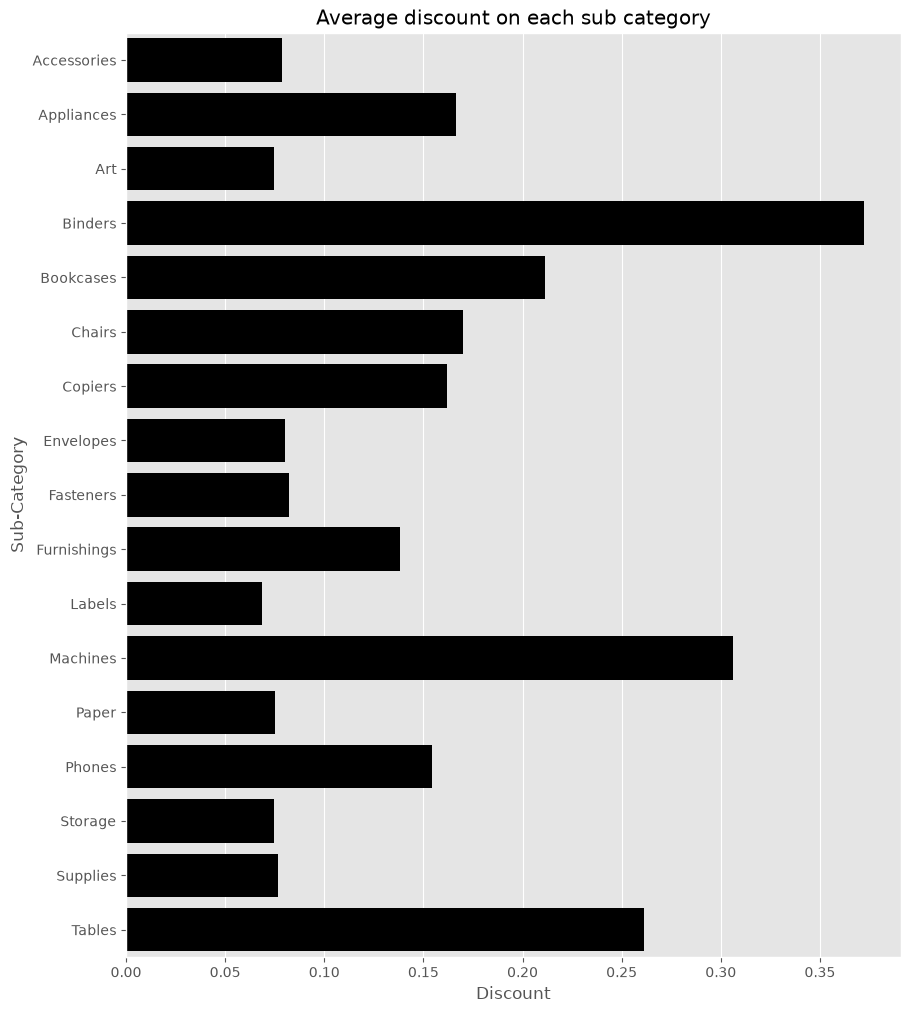

In [35]:
plt.figure(figsize=(10,12))
sns.barplot(x="Discount",y="Sub-Category",data=sub_category_discount,color="black")
plt.title("Average discount on each sub category")
plt.show()

### Observation

Binders receive the highest average discount (0.37), followed by Machines (0.31) and Tables (0.26). Accessories, Paper, Labels, and Storage receive some of the lowest average discounts.

### Insight

The company applies significantly different discount strategies across sub-categories instead of using a uniform pricing approach. High discounts are concentrated on only a few product groups.

### Recommendation

Evaluate whether sub-categories receiving high discounts are generating enough additional sales and profit to justify those discounts.

## Business Question 3

### Which region receives the highest average discount?

In [36]:
region_discount = df.groupby("Region")["Discount"].mean().reset_index()
region_discount

,Region,Discount
0,Central,0.24
1,East,0.15
2,South,0.15
3,West,0.11


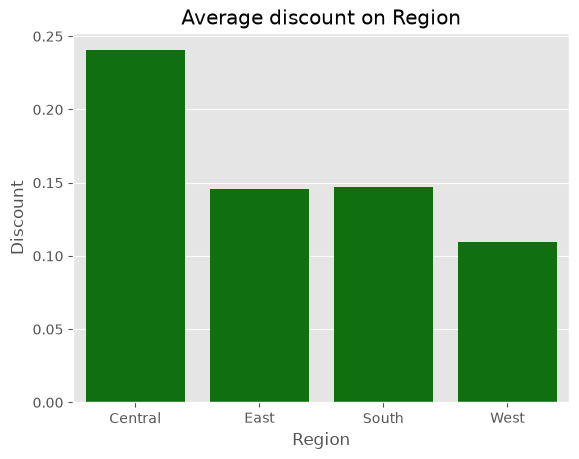

In [37]:
sns.barplot(x="Region",y="Discount",data=region_discount,color="green")
plt.title("Average discount on Region")
plt.show()

### Observation

The Central region receives the highest average discount (0.24%), while the West region receives the lowest average discount (0.11).

### Insight

The company appears to follow different pricing strategies across regions. Regions with higher discounts should be monitored to ensure discounts are improving business performance.

### Recommendation

Compare sales and profit in the Central region with other regions to determine whether higher discounts are producing better business results.

## Business Question 4

### Which states receive the highest average discount?

In [38]:
state_discount = df.groupby("State")["Discount"].mean().reset_index().sort_values(by="Discount", ascending=False).head(10)
state_discount

,State,Discount
11,Illinois,0.39
41,Texas,0.37
36,Pennsylvania,0.33
33,Ohio,0.32
4,Colorado,0.32
1,Arizona,0.30
8,Florida,0.30
40,Tennessee,0.29
35,Oregon,0.29
31,North Carolina,0.28


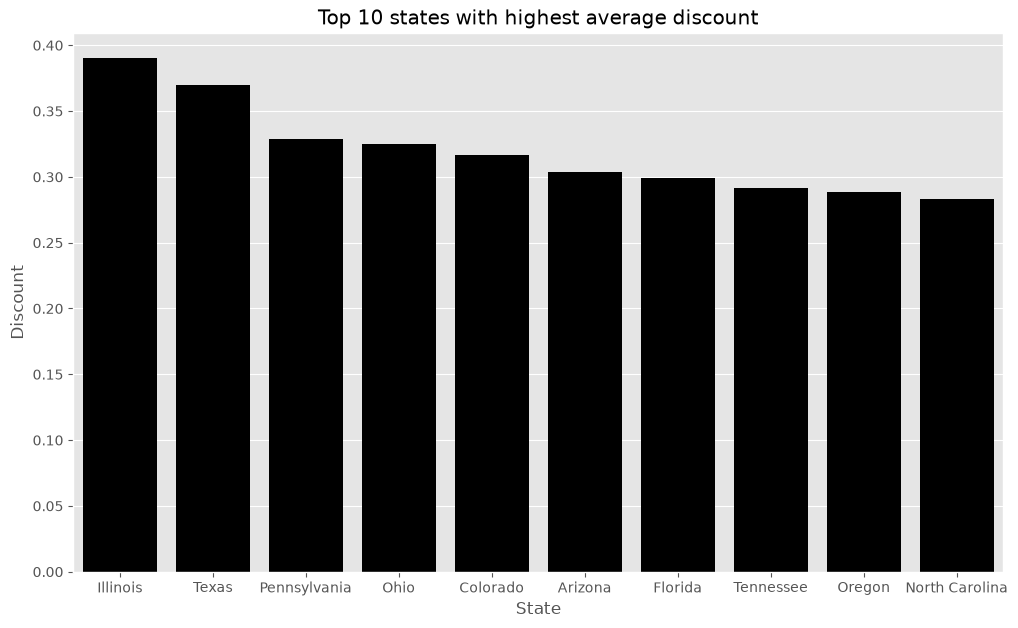

In [39]:
plt.figure(figsize=(12,7))
sns.barplot(x="State",y="Discount",data=state_discount,color="black")
plt.title("Top 10 states with highest average discount")
plt.show()

### Observation

Illinois has the highest average discount (0.39), followed by Texas (0.37) and Pennsylvania (0.33).

### Insight

A few states receive considerably higher discounts than the rest. These locations require additional analysis to determine whether higher discounts are improving sales or simply reducing profit.

### Recommendation

Review the pricing strategy in high-discount states and evaluate whether current discount levels are delivering a positive return for the business.

In [40]:
df["Year"].unique()

array([2016, 2015, 2014, 2017])

# Business Objective 5

## Analyze Sales & Profit Trends

This section analyzes sales and profit over time using the Year, Month, and Quarter features to identify business growth patterns and seasonal trends.

## Business Question 1

### How do sales vary by year?

In [41]:
year_sales = df.groupby("Year")["Sales"].sum().reset_index()
year_sales


,Year,Sales
0,2014,"484,247.50"
1,2015,"470,532.51"
2,2016,"609,205.60"
3,2017,"733,215.26"


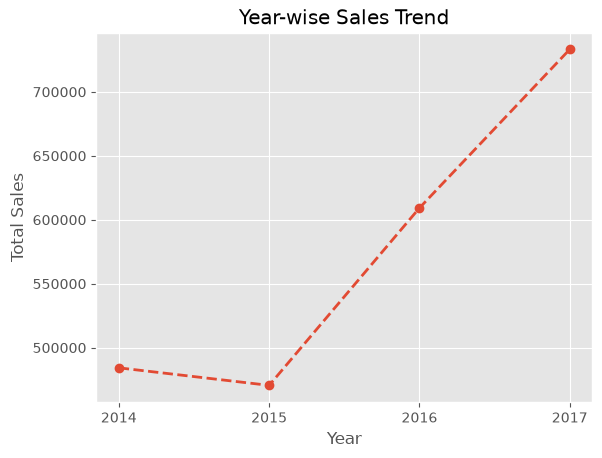

In [42]:
plt.plot(year_sales["Year"],year_sales["Sales"],marker = "o",linewidth=2,linestyle = "--")
plt.title("Year-wise Sales Trend")
plt.xticks(year_sales["Year"]) 
plt.xlabel("Year")
plt.ylabel("Total Sales")

plt.show()

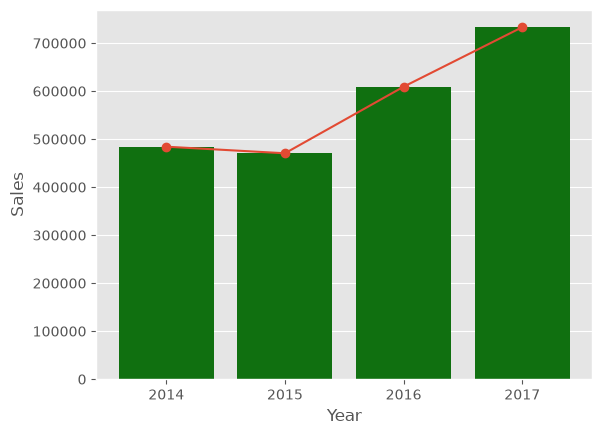

In [43]:
ax = sns.barplot(x="Year", y="Sales", data=year_sales, color="green")

ax.plot(
    year_sales["Year"].astype(str),
    year_sales["Sales"],
    marker="o"
)

### Observation

Sales increased consistently from 2014 to 2017. The highest sales were recorded in 2017, while 2014 recorded the lowest sales.

### Insight

The steady increase in yearly sales indicates that the business expanded successfully over the four-year period and was able to generate higher revenue each year.

### Recommendation

Review the factors that contributed to the strong sales growth in 2017 and continue implementing similar business strategies to sustain future growth.

## Business Question 2

### How do profits vary by year?

In [44]:
year_profit = df.groupby("Year")["Profit"].sum().reset_index()
year_profit


,Year,Profit
0,2014,"49,543.97"
1,2015,"61,618.60"
2,2016,"81,795.17"
3,2017,"93,439.27"


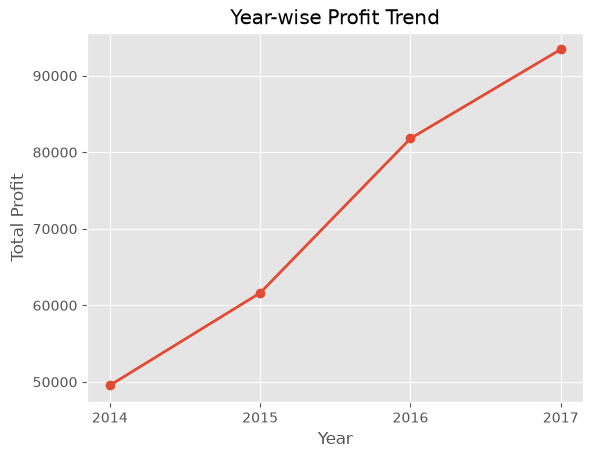

In [55]:
plt.plot(year_profit["Year"],year_profit["Profit"],marker = "o",linewidth=2)
plt.title("Year-wise Profit Trend")
plt.xticks(year_sales["Year"]) 
plt.xlabel("Year")
plt.ylabel("Total Profit")
plt.show()


### Observation

Profit also increased every year, rising from **49,543.97** in 2014 to **93,439.27** in 2017.

### Insight

The company is not only increasing sales but is also improving profitability over time, indicating healthy business growth.

### Recommendation

Continue monitoring yearly profit alongside sales to ensure future revenue growth also results in higher profitability.

## Business Question 3

### Which month generates the highest total sales?

In [46]:
sales_month = df.groupby("Month")["Sales"].sum().reset_index()
sales_month

,Month,Sales
0,1,"94,924.84"
1,2,"59,751.25"
2,3,"205,005.49"
3,4,"137,762.13"
4,5,"155,028.81"
5,6,"152,718.68"
6,7,"147,238.10"
7,8,"159,044.06"
8,9,"307,649.95"
9,10,"200,322.98"


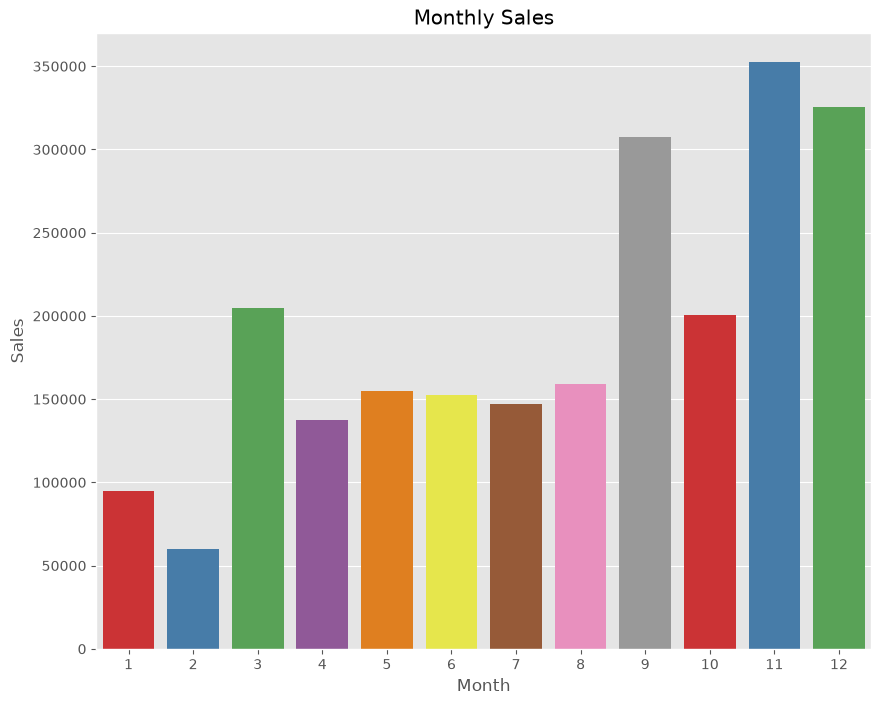

In [47]:
plt.figure(figsize=(10,8))
sns.barplot(x="Month",y="Sales",data=sales_month,hue="Month",palette="Set1",legend=False)
plt.title("Monthly Sales")
plt.show()

### Observation

November generated the highest total sales (**352,461.07**), followed by December (**325,293.50**) and September (**307,649.95**). February recorded the lowest sales (**59,751.25**).

### Insight

Sales are seasonal, with customer demand increasing significantly during the final months of the year.

### Recommendation

Increase inventory levels and marketing efforts before the high-sales months, especially September through December, to maximize revenue opportunities.

## Business Question 4

### Which month generates the highest total profit?

In [48]:
profit_month = df.groupby("Month")["Profit"].sum().reset_index()
profit_month

,Month,Profit
0,1,"9,134.45"
1,2,"10,294.61"
2,3,"28,594.69"
3,4,"11,587.44"
4,5,"22,411.31"
5,6,"21,285.80"
6,7,"13,832.66"
7,8,"21,776.94"
8,9,"36,857.48"
9,10,"31,784.04"


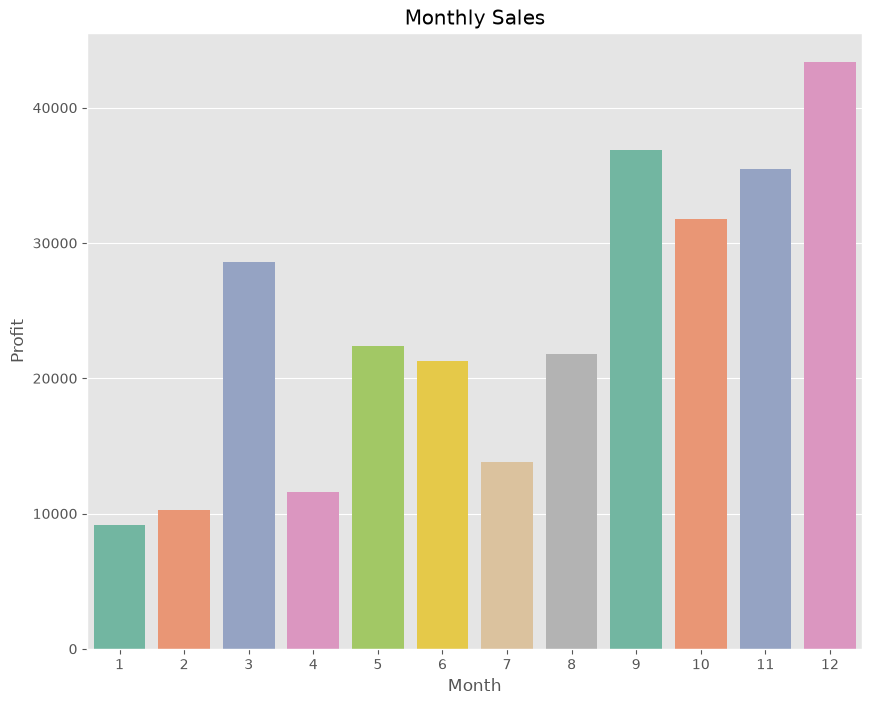

In [49]:
plt.figure(figsize=(10,8))
sns.barplot(x="Month",y="Profit",data=profit_month,hue="Month",palette="Set2",legend=False)
plt.title("Monthly Sales")
plt.show()

### Observation

December generated the highest total profit (**43,369.19**), followed by September (**36,857.48**) and November (**35,468.43**). January recorded the lowest profit (**9,134.45**).

### Insight

Although November achieved the highest sales, December generated the highest profit, indicating that higher sales do not always translate into the highest profitability.

### Recommendation

Analyze the pricing, product mix, and discount strategies used during December to understand what contributed to its strong profitability.

## Business Question 5

### Which quarter performs best in terms of sales and profit?

In [50]:
quaterly_performance = df.groupby("Quarter")[["Sales","Profit",]].sum().reset_index()
quaterly_performance

,Quarter,Sales,Profit
0,1,"359,681.58","48,023.74"
1,2,"445,509.62","55,284.54"
2,3,"613,932.11","72,467.08"
3,4,"878,077.56","110,621.66"


In [51]:
quarter_melt = quaterly_performance.melt(id_vars="Quarter",value_vars=["Sales", "Profit"],var_name="Metric",value_name="Value")
quarter_melt

,Quarter,Metric,Value
0,1,Sales,"359,681.58"
1,2,Sales,"445,509.62"
2,3,Sales,"613,932.11"
3,4,Sales,"878,077.56"
4,1,Profit,"48,023.74"
5,2,Profit,"55,284.54"
6,3,Profit,"72,467.08"
7,4,Profit,"110,621.66"


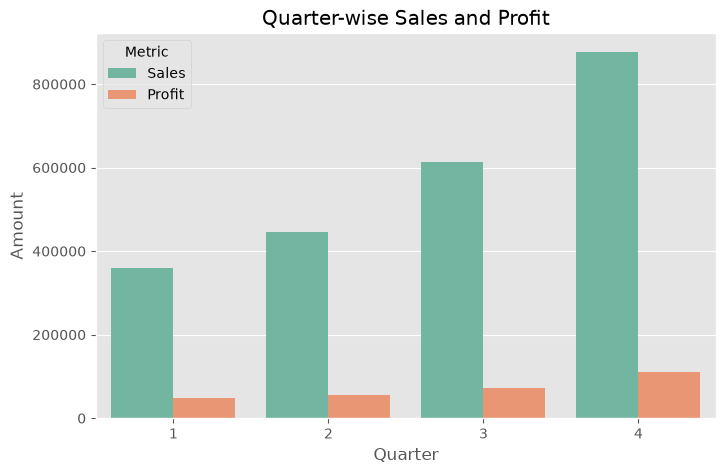

In [52]:
plt.figure(figsize=(8,5))

sns.barplot(data=quarter_melt,x="Quarter",y="Value",hue="Metric",palette="Set2")

plt.title("Quarter-wise Sales and Profit")
plt.xlabel("Quarter")
plt.ylabel("Amount")

plt.show()

### Observation

Quarter 4 generated the highest sales (**878,077.56**) and the highest profit (**110,621.66**). Quarter 1 recorded the lowest sales (**359,681.58**) and profit (**48,023.74**).

### Insight

Business performance improves throughout the year, with Quarter 4 contributing the largest share of both revenue and profit.

### Recommendation

Prepare inventory, marketing campaigns, and operational resources before Quarter 4 to meet increased customer demand and maximize business performance.

# Additional Analysis

## Correlation Between Key Numerical Variables

This section examines the correlation between Sales, Profit, Discount, and Quantity to statistically validate earlier findings.

<Axes: >

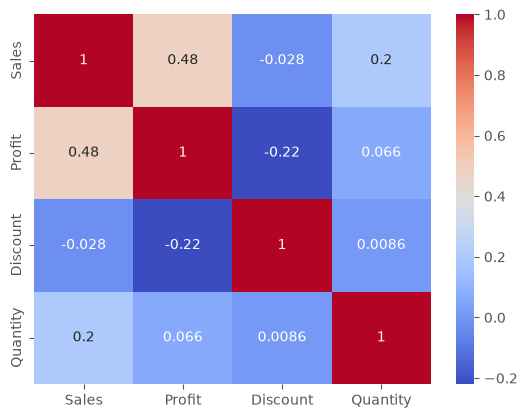

In [56]:
sns.heatmap(df[["Sales","Profit","Discount","Quantity"]].corr(), annot=True, cmap="coolwarm")

## Business Question 6

### Who are the top 10 customers by sales and profit?

In [57]:
## Business Question 5
### Who are the top 10 customers by total sales?

top_customers_sales = df.groupby("Customer Name")["Sales"].sum().reset_index().sort_values(by="Sales", ascending=False).head(10)
top_customers_sales

,Customer Name,Sales
686,Sean Miller,"25,043.05"
730,Tamara Chand,"19,052.22"
622,Raymond Buch,"15,117.34"
757,Tom Ashbrook,"14,595.62"
6,Adrian Barton,"14,473.57"
441,Ken Lonsdale,"14,175.23"
671,Sanjit Chand,"14,142.33"
334,Hunter Lopez,"12,873.30"
672,Sanjit Engle,"12,209.44"
156,Christopher Conant,"12,129.07"


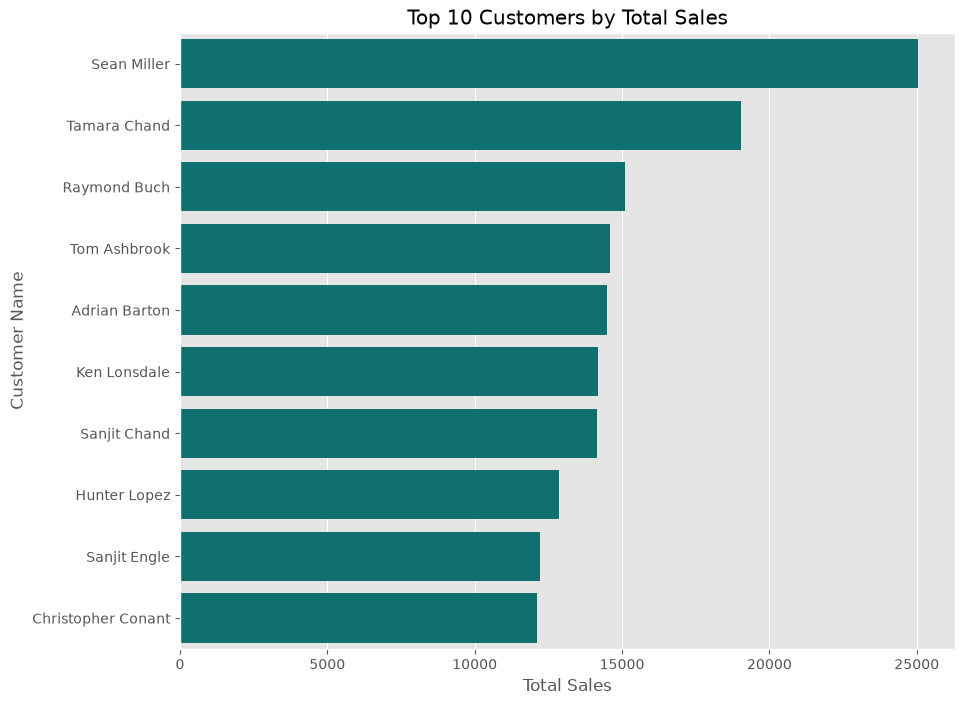

In [58]:
plt.figure(figsize=(10,8))
sns.barplot(x="Sales", y="Customer Name", data=top_customers_sales, color="teal")
plt.title("Top 10 Customers by Total Sales")
plt.xlabel("Total Sales")
plt.ylabel("Customer Name")
plt.show()

### Observation

Sean Miller generated the highest total sales (25,043), while Tamara Chand generated the highest total profit (8,981). Notably, Tamara Chand, Raymond Buch, and Sanjit Chand rank in the top 5 for both sales and profit, while Sean Miller — the #1 customer by sales — doesn't appear in the top 10 by profit at all.

### Insight

High sales volume doesn't guarantee high profit at the customer level either — the same pattern seen at category and regional level. A small group of customers (Tamara Chand, Raymond Buch, Sanjit Chand, Hunter Lopez, Adrian Barton) are consistently high-value across both metrics.

### Recommendation

Prioritize retention for the customers who rank high on both sales and profit, and investigate why high-sales customers like Sean Miller aren't converting into high profit — possible over-discounting on their orders.

In [59]:
top_customers_profit = df.groupby("Customer Name")["Profit"].sum().reset_index().sort_values(by="Profit", ascending=False).head(10)
top_customers_profit

,Customer Name,Profit
730,Tamara Chand,"8,981.32"
622,Raymond Buch,"6,976.10"
671,Sanjit Chand,"5,757.41"
334,Hunter Lopez,"5,622.43"
6,Adrian Barton,"5,444.81"
757,Tom Ashbrook,"4,703.79"
157,Christopher Martinez,"3,899.89"
431,Keith Dawkins,"3,038.63"
35,Andy Reiter,"2,884.62"
194,Daniel Raglin,"2,869.08"


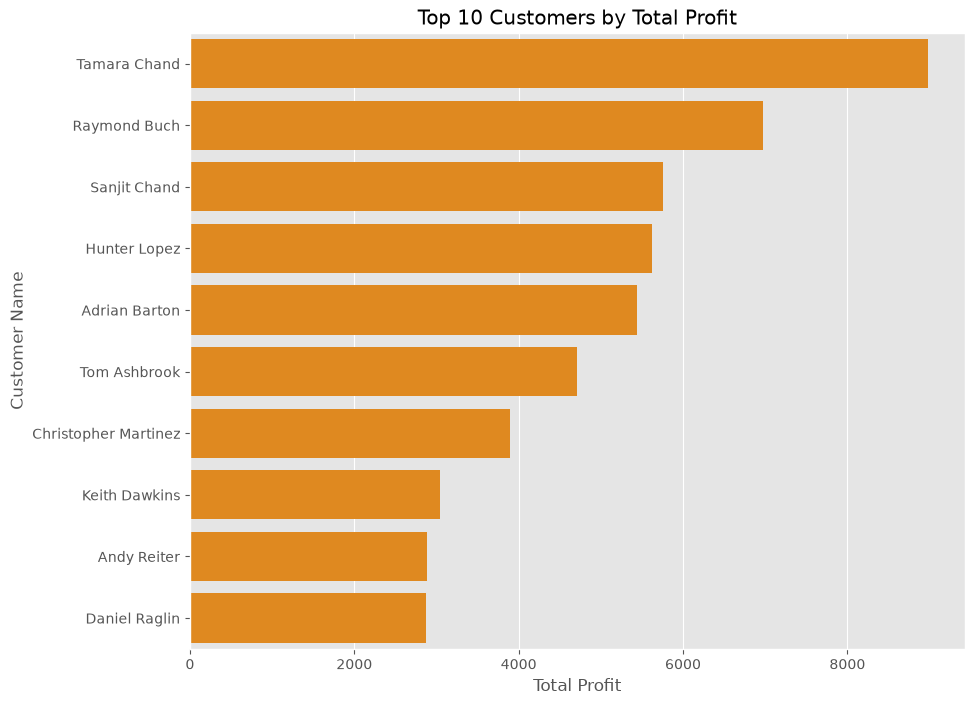

In [60]:
plt.figure(figsize=(10,8))
sns.barplot(x="Profit", y="Customer Name", data=top_customers_profit, color="darkorange")
plt.title("Top 10 Customers by Total Profit")
plt.xlabel("Total Profit")
plt.ylabel("Customer Name")
plt.show()